In [10]:
import tensorflow as tf
import keras.layers as tkl
from keras.callbacks import ModelCheckpoint
from keras.callbacks import CSVLogger
import matplotlib.pyplot as plt
import numpy as np
import os

# Load your dataset and split it into training and validation sets
data_dir = '/kaggle/input/trashnet/dataset-resized/'
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  label_mode='int',
  subset="training",
  seed = 1227,
  image_size=(224, 224),
  batch_size=32)

valid_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  label_mode='int',
  subset="validation",
  seed = 1227,
  image_size=(224, 224),
  batch_size=32)

class_names = train_ds.class_names
print(class_names)
num_classes = len(class_names)

val_batches = tf.data.experimental.cardinality(valid_ds)
test_ds = valid_ds.take(val_batches // 5)
valid_ds = valid_ds.skip(val_batches // 5)

print('Number of validation batches: %d' % tf.data.experimental.cardinality(valid_ds))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_ds))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Normalize the pixel values of the images to be in the range [-1, 1]
# normalization_layer = tkl.Rescaling(1./255)
# train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
# valid_ds = valid_ds.map(lambda x, y: (normalization_layer(x), y))
# test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))



# Use data augmentation to add more data for training
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

inputs = tf.keras.Input(shape=(224, 224, 3))
# Choose a pre-trained model to use as the basis for transfer learning
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the weights of the base model to prevent them from being updated during training
base_model.trainable = False
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
# The final layer should have as many units as there are classes
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

base_learning_rate = 0.0001
# Compile the model with a loss function and an optimizer
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              metrics=['accuracy'])

base_model.summary()

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of validation batches: 13
Number of test batches: 3
Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_5 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856

In [11]:
initial_epochs = 100

In [12]:
callbacks_list = [ModelCheckpoint(filepath='model.hdf5', monitor='val_accuracy',
                                   verbose=1, save_best_only=True, save_weights_only=False, mode='max')]
csv_logger = CSVLogger('modeltraining.log', separator=',', append=False)

# Train the model on the training set
history = model.fit(train_ds,
                    epochs=initial_epochs,
                    validation_data=(valid_ds),
                    callbacks=(callbacks_list+[csv_logger]))

Epoch 1/100
64/64 [==============================] - 6s 85ms/step - loss: 1.2751 - accuracy: 0.5682 - val_loss: 0.8220 - val_accuracy: 0.7237

Epoch 00001: val_accuracy improved from -inf to 0.72372, saving model to model.hdf5
Epoch 2/100
64/64 [==============================] - 6s 82ms/step - loss: 0.7851 - accuracy: 0.7230 - val_loss: 0.5527 - val_accuracy: 0.8093

Epoch 00002: val_accuracy improved from 0.72372 to 0.80929, saving model to model.hdf5
Epoch 3/100
64/64 [==============================] - 6s 83ms/step - loss: 0.6937 - accuracy: 0.7542 - val_loss: 0.5787 - val_accuracy: 0.8020

Epoch 00003: val_accuracy did not improve from 0.80929
Epoch 4/100
64/64 [==============================] - 6s 82ms/step - loss: 0.5893 - accuracy: 0.8022 - val_loss: 0.5336 - val_accuracy: 0.8068

Epoch 00004: val_accuracy did not improve from 0.80929
Epoch 5/100
64/64 [==============================] - 6s 83ms/step - loss: 0.5425 - accuracy: 0.8051 - val_loss: 0.5404 - val_accuracy: 0.8117

Epoc

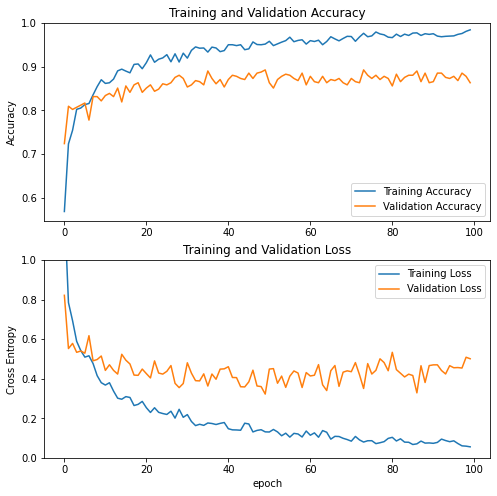

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [14]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 11

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

Number of layers in the base model:  19


In [15]:
# Unfreeze the base model layers and re-compile the model
base_model.trainable = True
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
sequential_1 (Sequential)    (None, 224, 224, 3)       0         
_________________________________________________________________
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
global_average_pooling2d_1 ( (None, 512)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 1024)              525312    
_________________________________________________________________
dense_4 (Dense)              (None, 1024)              1049

In [16]:
len(model.trainable_variables)

32

In [17]:
fine_tune_epochs = 200
total_epochs =  initial_epochs + fine_tune_epochs

In [18]:
# Fine-tune the model on the training set
history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=valid_ds,
                         callbacks=(callbacks_list+[csv_logger]))

Epoch 100/300
64/64 [==============================] - 17s 230ms/step - loss: 0.1229 - accuracy: 0.9575 - val_loss: 0.4837 - val_accuracy: 0.8753

Epoch 00100: val_accuracy did not improve from 0.89242
Epoch 101/300
64/64 [==============================] - 15s 228ms/step - loss: 0.0754 - accuracy: 0.9728 - val_loss: 0.5579 - val_accuracy: 0.8704

Epoch 00101: val_accuracy did not improve from 0.89242
Epoch 102/300
64/64 [==============================] - 15s 221ms/step - loss: 0.0853 - accuracy: 0.9728 - val_loss: 0.4654 - val_accuracy: 0.8753

Epoch 00102: val_accuracy did not improve from 0.89242
Epoch 103/300
64/64 [==============================] - 14s 221ms/step - loss: 0.0505 - accuracy: 0.9832 - val_loss: 0.4372 - val_accuracy: 0.9022

Epoch 00103: val_accuracy improved from 0.89242 to 0.90220, saving model to model.hdf5
Epoch 104/300
64/64 [==============================] - 14s 221ms/step - loss: 0.0479 - accuracy: 0.9817 - val_loss: 0.6337 - val_accuracy: 0.8533

Epoch 00104: 

In [19]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

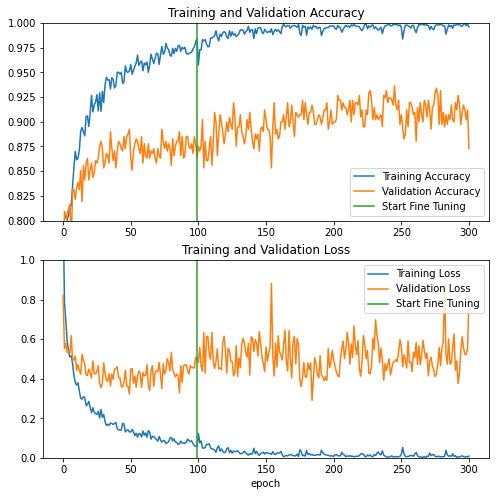

In [20]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [21]:
# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(test_ds)
print('Validation loss: {}, Validation accuracy: {}'.format(val_loss, val_acc))

3/3 [==============================] - 0s 64ms/step - loss: 0.7872 - accuracy: 0.8958
Validation loss: 0.7872023582458496, Validation accuracy: 0.8958333134651184


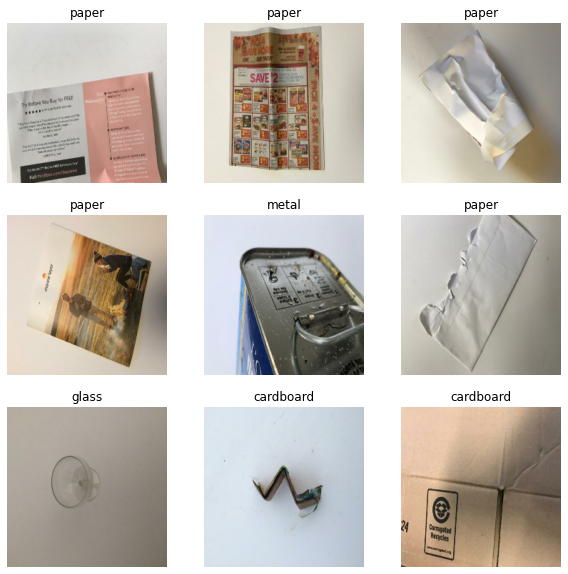

In [23]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_ds.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype("uint8"))
    plt.title(class_names[np.argmax(predictions[i])])
    plt.axis("off")